In [2]:
import os
from datetime import UTC

import dask
import fsspec
import icechunk
import pandas as pd
import xarray as xr
import yaml
from dask.diagnostics import ProgressBar
from nowcasting_datamodel.connection import DatabaseConnection
from nowcasting_datamodel.models.base import Base_Forecast
from pvlive_api import PVLive
from s3fs import S3FileSystem
from sqlalchemy import text
from tqdm import tqdm

from pvnet_app.data.nwp import ECMWFDownloader, UKVDownloader

/opt/miniforge3/envs/james-pvnet-app/lib/python3.12/site-packages/pydantic/_internal/_config.py:321: UserWarning: Valid config keys have changed in V2:
* 'allow_population_by_field_name' has been renamed to 'populate_by_name'
* 'orm_mode' has been renamed to 'from_attributes'
* 'underscore_attrs_are_private' has been removed
  warnings.warn(message, UserWarning)


In [3]:
start_date = "2025-10-14 00:00"
end_date = "2025-11-10 00:00"

start_date = pd.Timestamp(start_date)
end_date = pd.Timestamp(end_date)

ecmwf_s3_dir = "s3://nowcasting-nwp-development/ecmwf/data"
ukv_s3_dir = "s3://nowcasting-nwp-development/data-metoffice"
cloud_s3_dir = "s3://nowcasting-sat-development/cloudcasting_forecast"
sat_s3_icechunk = "s3://nowcasting-sat-development/rss/data/rss_uk3000m.icechunk"


local_raw_download_dir = "/home/james/tmp/live_inputs_raw"
local_output_dir = "/home/james/tmp/live_inputs_processed"

In [4]:


#os.makedirs(local_output_dir, exist_ok=False)

ecmwf_local_dir = f"{local_raw_download_dir}/ecmwf"
ukv_local_dir = f"{local_raw_download_dir}/ukv"
cloud_local_dir = f"{local_raw_download_dir}/cloudcasting"

for local_dir in [ecmwf_local_dir, ukv_local_dir, cloud_local_dir]:
    os.makedirs(local_dir, exist_ok=True)


In [ ]:
@dask.delayed
def download_zarr(fs: S3FileSystem, s3_path: str, local_dir: str) -> None:
    """Download a file from s3.
    
    Args:
        fs: The fsspec filesystem
        s3_path: The s3 path of the zarr
        local_dir: The local root directory to save the zarr to
    """
    zarr_name = os.path.basename(s3_path)
    fs.get(s3_path, f"{local_dir}/{zarr_name}", recursive=True)


def get_nwp_dataset(
    s3_dir: str, 
    datetime_fmt: str, 
    local_dir: str, 
    start_date: pd.Timestamp, 
    end_date:pd.Timestamp,
) -> xr.Dataset:
    """Download a collection of zarrs from s3 and open as a xarray dataset

    The files are downloaded to a supplied location on local disk before being opened. Files
    that already exist in this location will not be redownloaded. We filter the zarrs to ones which
    have a filename which is between the supplied start and end date.

    Args:
        s3_dir: Where to search for the zarrs
        datetime_fmt: The datetime format that zarrs are saved under. e.g. r"%Y%m%d%H" for zarr 
            which is named like 2025120100.zarr
        local_dir: Where to save the zarrs to in the local filesystem
        start_date: The start datetime used to filter the zarrs
        end_date: The end datetime used to filter the zarrs
    """

    if datetime_fmt not in [r"%Y%m%d%H", r"%Y-%m-%dT%H:%M"]:
        raise ValueError("This function has not been tested with the datetime format provided")

    # Convert the datetime format into a glob pattern
    glob_pattern = datetime_fmt
    for s, n in [("Y", 4), ("m", 2), ("d", 2), ("H", 2), ("M", 2)]:
        glob_pattern = glob_pattern.replace(r"%"+s, "[0-9]"*n)
    
    # Find the zarr files
    fs = fsspec.filesystem("s3")
    zarr_paths = fs.glob(f"{s3_dir}/{glob_pattern}.zarr")

    # Extract the timestamp from each path
    zarr_datetimes = [os.path.basename(p).removesuffix(".zarr") for p in zarr_paths]
    zarr_datetimes = pd.to_datetime(zarr_datetimes, format=datetime_fmt)

    # Filter to zarrs with datetime between the start and end dates
    zarr_paths = [path for path, dt in zip(zarr_paths, zarr_datetimes) if (start_date <= dt <= end_date)]

    # Filter out files already downloaded
    required_zarr_paths = [p for p in zarr_paths if not os.path.exists(f"{local_dir}/{os.path.basename(p)}")]
    
    # Download the files if required
    if len(required_zarr_paths)>0:

        # Download in parallel
        tasks = [download_zarr(fs, s3_path, local_dir) for s3_path in required_zarr_paths]
        with ProgressBar():
            _ = dask.compute(*tasks, scheduler="threads")

    # Open the datasets
    local_zarr_paths = [f"{local_dir}/{os.path.basename(p)}" for p in zarr_paths]

    return xr.open_mfdataset(local_zarr_paths, engine="zarr", decode_timedelta=True)


def filter_sat_times_to_available(ds_sat: xr.Dataset) -> xr.Dataset:
    """Filters the partially corrupt satellite dataset to timestamps which are available.

    Due to life-cycling in the s3 bucket, older parts of the icechunk data are deleted but without
    the timestamps being updated. This function filters the timestamps to find the minimum timestamp
    for which the corresponding data has not been deleted by lifecycling.
    
    Args:
        ds_sat: The satellite dataset opened from icechunk
    """

    def check_time_available(i: int) -> bool:
        try:
            ds_sat.isel(time=i, variable=0).compute()
            return True
        except icechunk.IcechunkError:
            return False

    N = len(ds_sat.time)

    # If the first timestamp is avaialble we assume all timestamps are available
    if check_time_available(0):
        return ds_sat

    # If the last timestamp is available we assume none of the timestamps are available
    elif not check_time_available(N-1):
        raise Exception("No sat data available")

    # Otherwise we do an efficient search for the first timestamp for which data is available
    else:
        available_indexes = [N-1]
        unavailable_indexes = [0]

        first_available_index = None
        while first_available_index is None:

            i = (max(unavailable_indexes) + min(available_indexes))//2

            # Available
            if check_time_available(i):
                available_indexes.append(i)
                if i-1 in unavailable_indexes:
                    first_available_index = i

            # Unavailable
            else:
                unavailable_indexes.append(i)
                if i+1 in available_indexes:
                    first_available_index = i+1

        return ds_sat.isel(time=slice(first_available_index, None))            


def get_sat_dataset(
    s3_path: str,
    start_date: pd.Timestamp, 
    end_date:pd.Timestamp,
) -> xr.Dataset:
    """Open the satellite data from s3 incechunk and filter to date period
    
    Args:
        s3_path: The path on s3 to the icechunk
        start_date: The start datetime of the period
        end_date: The end datetime of the period
    """

    bucket, _, path = s3_path.removeprefix("s3://").partition("/")
    store = icechunk.s3_storage(
        bucket=bucket,
        prefix=path,
        from_env=True,
        region='eu-west-1',
    )

    repo = icechunk.Repository.open(store)
    session = repo.readonly_session("main")

    ds = xr.open_zarr(session.store)

    # Need to modify the area attr to correct format
    area_sring = yaml.dump(ds.attrs["area"])
    ds.attrs["area"] = ds.data.attrs["area"] = area_sring

    ds = ds.sel(time=slice(start_date, end_date))

    return filter_sat_times_to_available(ds)


def get_api_pvlive_dataset(
    start_date: pd.Timestamp, 
    end_date: pd.Timestamp,
) -> xr.Dataset:
    """Get data from PVLive for the given period from the PVLive API
    
    Args:
        start_date: The start datetime of the period
        end_date: The end datetime of the period
    """

    py_start_date = start_date.to_pydatetime().replace(tzinfo=timezone.utc)
    py_end_date = end_date.to_pydatetime().replace(tzinfo=timezone.utc)

    pvl = PVLive()

    ds_gsp_list = []
    for gsp_id in tqdm(pvl.gsp_ids):
        df = pvl.between(
            start=py_start_date,
            end=py_end_date,
            entity_type="gsp",
            entity_id=gsp_id,
            extra_fields="capacity_mwp",
            dataframe=True,
        )

        df["datetime_gmt"] = df["datetime_gmt"].dt.tz_localize(None)

        ds = (
            df.set_index("datetime_gmt")
            .drop("gsp_id", axis=1)
            .to_xarray()
            .expand_dims(gsp_id=[gsp_id])
        )
        
        ds_gsp_list.append(ds)

    return xr.concat(ds_gsp_list, dim="gsp_id")



def save(ds: xr.Dataset, chunk_dict: dict[str, int], save_path: str) -> None:
    """Rechunk and save the xarray dataset to zarr storage.
    
    Args:
        ds: The xarray Dataset to save
        chunk_dict: Dictionary of chunk sizes for all dimensions in the data
        save_path: Path to save the zarr under
    """

    if "variable" in ds:
        ds["variable"] = ds["variable"].astype(str)

    # Clear old encoding
    for v in list(ds.variables.keys()):
        ds[v].encoding.clear()

    ds.chunk(chunk_dict).to_zarr(save_path)

In [6]:
from nowcasting_datamodel.connection import DatabaseConnection
from nowcasting_datamodel.models.base import Base_Forecast
from sqlalchemy import text


def get_db_pvlive_dataset(
    start_date: pd.Timestamp,
    end_date: pd.Timestamp,
    updated: bool,
) -> xr.Dataset:
    """Get data from PVLive for the given period from the OCF database
    
    Args:
        start_date: The start datetime of the period
        end_date: The end datetime of the period
        updated: Whether to get the in-day initial estimates or the updated values which are created
            the day after.
    """

    if "OCF_DB_URL" not in os.environ:
        raise Exception(
            "To get the PVLive values from the database the environmental variable `OCF_DB_URL` "
            "must be set"
        )

    db_connection = DatabaseConnection(url=os.environ["OCF_DB_URL"], base=Base_Forecast)

    with db_connection.engine.connect() as conn:

        pvlive_cols = """
            g.datetime_utc,
            g.solar_generation_kw,
            g.capacity_mwp,
            l.gsp_id
        """

        regime = "day-after" if updated else "in-day"

        query = text(f"""
            SELECT {pvlive_cols}
            FROM gsp_yield AS g
            JOIN location AS l ON g.location_id = l.id
            WHERE g.regime='{regime}'
            AND g.datetime_utc>='{start_date}'
            AND g.datetime_utc<='{end_date}'
        """)
        
        df_pvlive = pd.DataFrame(
            conn.execute(query).fetchall(),
            columns=["datetime_utc", "solar_generation_kw", "capacity_mwp", "gsp_id"]
        )
        
    df_pvlive["generation_mw"] = df_pvlive.solar_generation_kw * 1e-3
    del df_pvlive["solar_generation_kw"]
        
    # Convert to xarray
    return df_pvlive.set_index(["datetime_gmt", "gsp_id"]).to_xarray()


/opt/miniforge3/envs/james-pvnet-app/lib/python3.12/site-packages/pydantic/_internal/_config.py:321: UserWarning: Valid config keys have changed in V2:
* 'allow_population_by_field_name' has been renamed to 'populate_by_name'
* 'orm_mode' has been renamed to 'from_attributes'
* 'underscore_attrs_are_private' has been removed
  warnings.warn(message, UserWarning)


In [6]:
get_nwp_dataset(
    s3_dir=ecmwf_s3_dir,
    datetime_fmt=r"%Y%m%d%H",  # IFS zarr files in form YYYYmmddHH.zarr
    start_date=start_date, 
    end_date=end_date,
    local_dir=ecmwf_local_dir,
)

['nowcasting-nwp-development/ecmwf/data/2025110318.zarr',
 'nowcasting-nwp-development/ecmwf/data/2025110412.zarr',
 'nowcasting-nwp-development/ecmwf/data/2025110418.zarr',
 'nowcasting-nwp-development/ecmwf/data/2025110500.zarr',
 'nowcasting-nwp-development/ecmwf/data/2025110506.zarr',
 'nowcasting-nwp-development/ecmwf/data/2025110512.zarr',
 'nowcasting-nwp-development/ecmwf/data/2025110518.zarr',
 'nowcasting-nwp-development/ecmwf/data/2025110600.zarr',
 'nowcasting-nwp-development/ecmwf/data/2025110606.zarr',
 'nowcasting-nwp-development/ecmwf/data/2025110612.zarr',
 'nowcasting-nwp-development/ecmwf/data/2025110618.zarr',
 'nowcasting-nwp-development/ecmwf/data/2025110700.zarr',
 'nowcasting-nwp-development/ecmwf/data/2025110706.zarr',
 'nowcasting-nwp-development/ecmwf/data/2025110712.zarr',
 'nowcasting-nwp-development/ecmwf/data/2025110718.zarr',
 'nowcasting-nwp-development/ecmwf/data/2025110800.zarr',
 'nowcasting-nwp-development/ecmwf/data/2025110806.zarr',
 'nowcasting-n

In [5]:
ds_ecmwf = get_nwp_dataset(
    s3_dir=ecmwf_s3_dir,
    datetime_fmt=r"%Y%m%d%H",  # IFS zarr files in form YYYYmmddHH.zarr
    start_date=start_date, 
    end_date=end_date,
    local_dir=ecmwf_local_dir,
)

In [6]:
ds_ecmwf = ECMWFDownloader.rename_variables(ds_ecmwf)

In [7]:
chunk_dict = {
    "init_time": 1,
    "step": 10,
    "latitude": 50,
    "longitude": 50,
    "variable": len(ds_ecmwf.variable)
}

save(ds_ecmwf, chunk_dict, f"{local_output_dir}/ecmwf.zarr")


/home/james/.local/lib/python3.12/site-packages/zarr/core/dtype/npy/string.py:248: UnstableSpecificationWarning: The data type (FixedLengthUTF32(length=5, endianness='little')) does not have a Zarr V3 specification. That means that the representation of arrays saved with this data type may change without warning in a future version of Zarr Python. Arrays stored with this data type may be unreadable by other Zarr libraries. Use this data type at your own risk! Check https://github.com/zarr-developers/zarr-extensions/tree/main/data-types for the status of data type specifications for Zarr V3.
  v3_unstable_dtype_warning(self)
/home/james/.local/lib/python3.12/site-packages/zarr/api/asynchronous.py:228: UserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


In [7]:
ds_ukv = get_nwp_dataset(
    s3_dir=ukv_s3_dir,
    datetime_fmt=r"%Y%m%d%H",  # UKV zarr files in form YYYYmmddHH.zarr
    start_date=start_date, 
    end_date=end_date,
    local_dir=ukv_local_dir,
)

In [8]:
ds_ukv = ds_ukv.chunk({"step": -1, "variable": -1})

In [9]:
ds_ukv = UKVDownloader.rename_variables(ds_ukv)
ds_ukv = UKVDownloader.add_lon_lat_coords(ds_ukv)
ds_ukv = UKVDownloader.regrid(ds_ukv, split_by_step=False)
ds_ukv = UKVDownloader.fix_dtype(ds_ukv)

/opt/miniforge3/envs/james-pvnet-app/lib/python3.12/site-packages/pyproj/crs/crs.py:143: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)
/opt/miniforge3/envs/james-pvnet-app/lib/python3.12/site-packages/h5py/__init__.py:36: UserWarning: h5py is running against HDF5 1.14.4 when it was built against 1.14.6, this may cause problems
  _warn(("h5py is running against HDF5 {0} when it was built against {1}, "


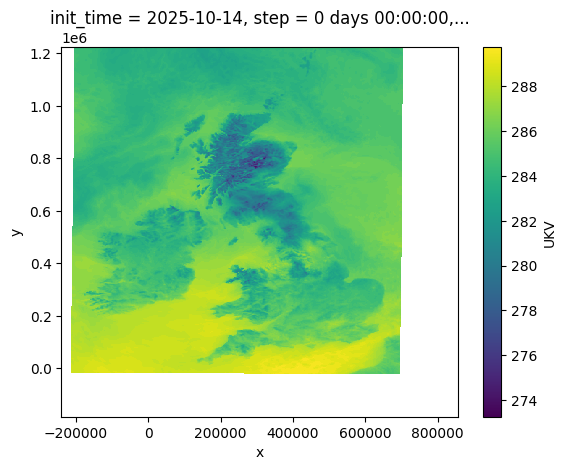

In [10]:
ds_ = ds_ukv.isel(init_time=0, step=0).sel(variable="t").UKV

ds_.where(ds_>0).plot()

In [11]:
chunk_dict = {
    "init_time": 1,
    "step": 10,
    "x": 100,
    "y": 100,
    "variable": len(ds_ukv.variable)
}

with np.errstate(over='ignore'):
    save(ds_ukv, chunk_dict, f"{local_output_dir}/ukv.zarr")

/home/james/.local/lib/python3.12/site-packages/zarr/core/dtype/npy/string.py:248: UnstableSpecificationWarning: The data type (FixedLengthUTF32(length=6, endianness='little')) does not have a Zarr V3 specification. That means that the representation of arrays saved with this data type may change without warning in a future version of Zarr Python. Arrays stored with this data type may be unreadable by other Zarr libraries. Use this data type at your own risk! Check https://github.com/zarr-developers/zarr-extensions/tree/main/data-types for the status of data type specifications for Zarr V3.
  v3_unstable_dtype_warning(self)
/home/james/.local/lib/python3.12/site-packages/zarr/api/asynchronous.py:228: UserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(
/opt/miniforge3/envs/james-pvnet-app/lib/python3.12/site-packages/dask/array/chunk.py:279: Runti

KeyboardInterrupt: 

In [ ]:
ds_cloud = get_nwp_dataset(
    s3_dir=cloud_s3_dir,
    datetime_fmt=r"%Y-%m-%dT%H:%M",  # Zarr files in form YYYY-mm-ddTHH:MM.zarr
    start_date=start_date, 
    end_date=end_date,
    local_dir=cloud_local_dir,
)

100%|██████████| 47/47 [04:08<00:00,  5.29s/it]


In [ ]:
ds_cloud

<xarray.Dataset> Size: 6GB
Dimensions:          (init_time: 49, variable: 11, step: 12,
                      y_geostationary: 372, x_geostationary: 614)
Coordinates:
  * init_time        (init_time) datetime64[ns] 392B 2025-11-03 ... 2025-11-04
  * step             (step) timedelta64[ns] 96B 00:15:00 00:30:00 ... 03:00:00
  * variable         (variable) object 88B 'IR_016' 'IR_039' ... 'WV_073'
  * x_geostationary  (x_geostationary) float64 5kB 1.5e+04 ... -1.824e+06
  * y_geostationary  (y_geostationary) float64 3kB 4.192e+06 ... 5.305e+06
Data variables:
    sat_pred         (init_time, variable, step, y_geostationary, x_geostationary) float32 6GB dask.array<chunksize=(1, 3, 3, 93, 307), meta=np.ndarray>

In [ ]:
chunk_dict = {
    "init_time": 1,
    "step": 10,
    "x_geostationary": 100,
    "y_geostationary": 100,
    "variable": len(ds_cloud.variable)
}

save(ds_cloud, chunk_dict, f"{local_output_dir}/cloudcasting.zarr")


/home/james/.local/lib/python3.12/site-packages/zarr/core/dtype/npy/string.py:248: UnstableSpecificationWarning: The data type (FixedLengthUTF32(length=6, endianness='little')) does not have a Zarr V3 specification. That means that the representation of arrays saved with this data type may change without warning in a future version of Zarr Python. Arrays stored with this data type may be unreadable by other Zarr libraries. Use this data type at your own risk! Check https://github.com/zarr-developers/zarr-extensions/tree/main/data-types for the status of data type specifications for Zarr V3.
  v3_unstable_dtype_warning(self)
/home/james/.local/lib/python3.12/site-packages/zarr/api/asynchronous.py:228: UserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


In [44]:

ds_sat = get_sat_dataset(sat_s3_icechunk, start_date, end_date)

In [45]:
ds_sat

<xarray.Dataset> Size: 42GB
Dimensions:          (time: 3432, y_geostationary: 412, x_geostationary: 681,
                      variable: 11)
Coordinates:
  * time             (time) datetime64[ns] 27kB 2025-10-27 ... 2025-11-10
  * x_geostationary  (x_geostationary) float64 5kB 1.14e+05 ... -1.926e+06
  * variable         (variable) object 88B 'IR_016' 'IR_039' ... 'WV_073'
  * y_geostationary  (y_geostationary) float64 3kB 4.123e+06 ... 5.356e+06
Data variables:
    data             (time, y_geostationary, x_geostationary, variable) float32 42GB dask.array<chunksize=(1, 412, 681, 1), meta=np.ndarray>
Attributes: (12/13)
    reader:                   seviri_l1b_native
    sensor:                   seviri
    modifiers:                ()
    platform_name:            Meteosat-11
    area:                     msg_seviri_rss_3km:\n  area_extent:\n    lower_...
    time_parameters:          {'nominal_start_time': '2025-11-10T10:20:00', '...
    ...                       ...
    resolution:               3000.403165817
    end_time:                 2025-11-10 10:25:00
    georef_offset_corrected:  True
    ancillary_variables:      []
    orbital_parameters:       {'projection_longitude': '9.5', 'projection_lat...
    variables:                {'IR_134': {'units': 'K', 'wavelength': '13.4\x...

In [ ]:
chunk_dict = {
    "time": 1,
    "x_geostationary": 100,
    "y_geostationary": 100,
    "variable": len(ds_sat.variable)
}

save(ds_sat, chunk_dict, f"{local_output_dir}/rss.zarr")

/home/james/.local/lib/python3.12/site-packages/zarr/core/dtype/npy/string.py:248: UnstableSpecificationWarning: The data type (FixedLengthUTF32(length=6, endianness='little')) does not have a Zarr V3 specification. That means that the representation of arrays saved with this data type may change without warning in a future version of Zarr Python. Arrays stored with this data type may be unreadable by other Zarr libraries. Use this data type at your own risk! Check https://github.com/zarr-developers/zarr-extensions/tree/main/data-types for the status of data type specifications for Zarr V3.
  v3_unstable_dtype_warning(self)
/home/james/.local/lib/python3.12/site-packages/zarr/api/asynchronous.py:228: UserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


In [ ]:
ds_gsp = get_pvlive_dataset(start_date, end_date)

100%|██████████| 332/332 [00:18<00:00, 17.65it/s]


In [ ]:
ds_gsp

<xarray.Dataset> Size: 263kB
Dimensions:        (gsp_id: 332, datetime_gmt: 49)
Coordinates:
  * datetime_gmt   (datetime_gmt) datetime64[ns] 392B 2025-11-03 ... 2025-11-04
  * gsp_id         (gsp_id) int64 3kB 0 1 2 3 4 6 7 ... 337 338 339 340 341 342
Data variables:
    generation_mw  (gsp_id, datetime_gmt) float64 130kB 0.0 0.0 0.0 ... 0.0 0.0
    capacity_mwp   (gsp_id, datetime_gmt) float64 130kB 2.024e+04 ... 1.43

In [ ]:

chunk_dict = {
    "gsp_id": len(ds_gsp.gsp_id),
    "datetime_gmt": 200,
}

save(ds_gsp, chunk_dict, f"{local_output_dir}/pvlive_data.zarr")



/home/james/.local/lib/python3.12/site-packages/zarr/api/asynchronous.py:228: UserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


In [ ]:
def get_db_pvlive_dataset(
    start_date: pd.Timestamp,
    end_date: pd.Timestamp,
    updated: bool,
) -> xr.Dataset:
    """Get data from PVLive for the given period from the OCF database
    
    Args:
        start_date: The start datetime of the period
        end_date: The end datetime of the period
        updated: Whether to get the in-day initial estimates or the updated values which are created
            the day after.
    """

    if "OCF_DB_URL" not in os.environ:
        raise Exception(
            "To get the PVLive values from the database the environmental variable `OCF_DB_URL` "
            "must be set"
        )

    db_connection = DatabaseConnection(url=os.environ["OCF_DB_URL"], base=Base_Forecast)

    with db_connection.engine.connect() as conn:

        pvlive_cols = """
            g.datetime_utc,
            g.solar_generation_kw,
            g.capacity_mwp,
            l.gsp_id
        """

        regime = "day-after" if updated else "in-day"

        query = text(
            f"""
            SELECT {pvlive_cols}
            FROM gsp_yield AS g
            JOIN location AS l ON g.location_id = l.id
            WHERE g.regime='{regime}'
            AND g.datetime_utc>='{start_date}'
            AND g.datetime_utc<='{end_date}'
            """
        ) # noqa: S608
        
        df_pvlive = pd.DataFrame(
            conn.execute(query).fetchall(),
            columns=["datetime_gmt", "solar_generation_kw", "capacity_mwp", "gsp_id"]
        )
        
    df_pvlive["generation_mw"] = df_pvlive.solar_generation_kw * 1e-3
    del df_pvlive["solar_generation_kw"]
        
    # Convert to xarray
    return df_pvlive.set_index(["datetime_gmt", "gsp_id"]).to_xarray()

get_db_pvlive_dataset(start_date, start_date+pd.Timedelta("30min"), updated=False)

2025-11-10 15:33:55,334 INFO sqlalchemy.engine.Engine select pg_catalog.version()
2025-11-10 15:33:55,335 INFO sqlalchemy.engine.Engine [raw sql] {}
2025-11-10 15:33:55,364 INFO sqlalchemy.engine.Engine select current_schema()
2025-11-10 15:33:55,364 INFO sqlalchemy.engine.Engine [raw sql] {}
2025-11-10 15:33:55,393 INFO sqlalchemy.engine.Engine show standard_conforming_strings
2025-11-10 15:33:55,394 INFO sqlalchemy.engine.Engine [raw sql] {}
2025-11-10 15:33:55,422 INFO sqlalchemy.engine.Engine BEGIN (implicit)
2025-11-10 15:33:55,423 INFO sqlalchemy.engine.Engine 
            SELECT 
            g.datetime_utc,
            g.solar_generation_kw,
            g.capacity_mwp,
            l.gsp_id
        
            FROM gsp_yield AS g
            JOIN location AS l ON g.location_id = l.id
            WHERE g.regime='in-day'
            AND g.datetime_utc>='2025-10-14 00:00:00'
            AND g.datetime_utc<='2025-10-14 00:30:00'
        
2025-11-10 15:33:55,423 INFO sqlalchemy.engin

<xarray.Dataset> Size: 13kB
Dimensions:        (datetime_gmt: 2, gsp_id: 332)
Coordinates:
  * datetime_gmt   (datetime_gmt) datetime64[ns] 16B 2025-10-14 2025-10-14T00...
  * gsp_id         (gsp_id) int64 3kB 0 1 2 3 4 6 7 ... 337 338 339 340 341 342
Data variables:
    capacity_mwp   (datetime_gmt, gsp_id) float64 5kB 1.974e+04 198.5 ... 1.376
    generation_mw  (datetime_gmt, gsp_id) float64 5kB 0.0 0.0 0.0 ... 0.0 0.0